In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", None)

In [2]:
# Paths


PROJECT_ROOT = Path.cwd().parent

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

In [3]:
# Load Dataset

scaled_df = pd.read_parquet(
    DATA_PROCESSED / "scaled_features.parquet"
)

print(scaled_df.shape)

scaled_df.head()

(93358, 11)


,recency_days,frequency,monetary_value,total_items,freight_to_merchandise_ratio,avg_installments,avg_review_score,review_coverage_ratio,unique_products,unique_categories,unique_sellers
0,-0.461207,0.0,0.375114,0.0,-0.535578,2.000000,0.0,0.0,0.0,0.0,0.0
1,-0.448276,0.0,-0.661422,0.0,0.870328,-0.333333,-1.0,0.0,0.0,0.0,0.0
2,1.375000,0.0,-0.193580,0.0,0.102667,2.000000,-2.0,0.0,0.0,0.0,0.0
3,0.443966,0.0,-0.595214,0.0,1.843668,0.666667,-1.0,0.0,0.0,0.0,0.0
4,0.301724,0.0,0.842956,0.0,-0.529672,1.333333,0.0,0.0,0.0,0.0,0.0


In [4]:
# Validation

validation = pd.Series({
    "rows": len(scaled_df),
    "columns": len(scaled_df.columns),
    "missing_values": scaled_df.isna().sum().sum(),
    "duplicate_rows": scaled_df.duplicated().sum()
})

validation

rows              93358
columns              11
missing_values        0
duplicate_rows      792
dtype: int64

In [5]:
# Feature Matrix
# We'll create the matrix used by K-Means.

X = scaled_df.copy()

print(X.shape)

(93358, 11)


In [6]:
# Elbow Method

inertia = []

k_values = range(2, 9)

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X)

    inertia.append(model.inertia_)

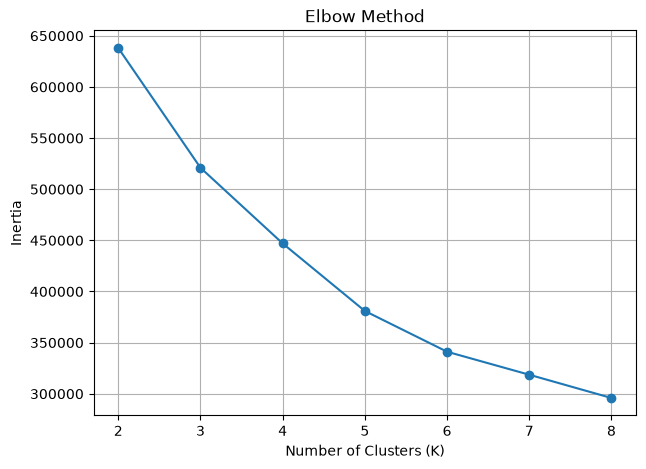

In [7]:
# Plot

plt.figure(figsize=(7,5))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [8]:
# Silhouette Score


silhouette_scores = []

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X)

    score = silhouette_score(
        X,
        labels
    )

    silhouette_scores.append(score)

In [9]:
# Results Table


results = pd.DataFrame({

    "K": k_values,

    "Inertia": inertia,

    "Silhouette Score": silhouette_scores

})

results

,K,Inertia,Silhouette Score
0,2,638056.623717,0.640783
1,3,520983.966316,0.348086
2,4,446994.916273,0.316697
3,5,380935.355035,0.344303
4,6,341108.317559,0.300445
5,7,318626.162483,0.245489
6,8,295875.579748,0.243327


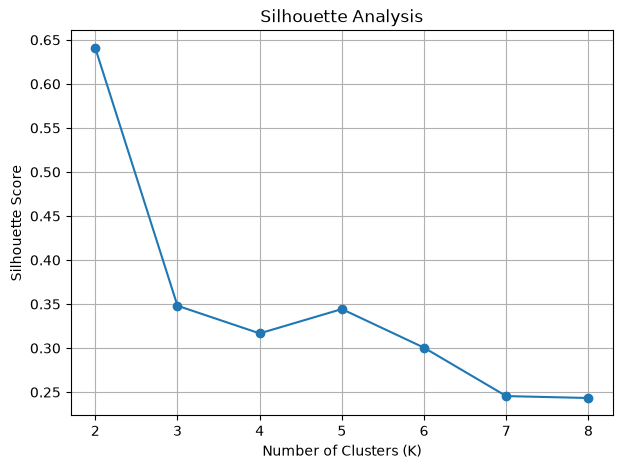

In [10]:
# Silhouette Plot

plt.figure(figsize=(7,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.grid(True)

plt.show()

In [11]:
for k in [3, 4, 5]:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X)

    print(f"\nK = {k}")

    print(pd.Series(labels).value_counts().sort_index())


K = 3
0    71163
1     3297
2    18898
Name: count, dtype: int64

K = 4
0    12140
1     3037
2    60714
3    17467
Name: count, dtype: int64

K = 5
0     9724
1    16825
2      768
3     7066
4    58975
Name: count, dtype: int64


In [12]:
# Compare Cluster Sizes# 

for k in [3, 4, 5]:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    print(f"\n===== K = {k} =====")
    print(pd.Series(labels).value_counts().sort_index())


===== K = 3 =====
0    71163
1     3297
2    18898
Name: count, dtype: int64

===== K = 4 =====
0    12140
1     3037
2    60714
3    17467
Name: count, dtype: int64

===== K = 5 =====
0     9724
1    16825
2      768
3     7066
4    58975
Name: count, dtype: int64


In [15]:

for k in [3, 4, 5]:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    print(f"\n===== K = {k} =====")
    print(pd.Series(labels).value_counts().sort_index())


===== K = 3 =====
0    71163
1     3297
2    18898
Name: count, dtype: int64

===== K = 4 =====
0    12140
1     3037
2    60714
3    17467
Name: count, dtype: int64

===== K = 5 =====
0     9724
1    16825
2      768
3     7066
4    58975
Name: count, dtype: int64


In [16]:
BEST_K = 4

kmeans = KMeans(
    n_clusters=BEST_K,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X)

clustered_df = scaled_df.copy()
clustered_df["cluster"] = cluster_labels

clustered_df.head()

,recency_days,frequency,monetary_value,total_items,freight_to_merchandise_ratio,avg_installments,avg_review_score,review_coverage_ratio,unique_products,unique_categories,unique_sellers,cluster
0,-0.461207,0.0,0.375114,0.0,-0.535578,2.000000,0.0,0.0,0.0,0.0,0.0,2
1,-0.448276,0.0,-0.661422,0.0,0.870328,-0.333333,-1.0,0.0,0.0,0.0,0.0,2
2,1.375000,0.0,-0.193580,0.0,0.102667,2.000000,-2.0,0.0,0.0,0.0,0.0,3
3,0.443966,0.0,-0.595214,0.0,1.843668,0.666667,-1.0,0.0,0.0,0.0,0.0,0
4,0.301724,0.0,0.842956,0.0,-0.529672,1.333333,0.0,0.0,0.0,0.0,0.0,2


In [17]:
for k in [3, 4, 5]:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    print(f"\n===== K = {k} =====")
    print(pd.Series(labels).value_counts().sort_index())


===== K = 3 =====
0    71163
1     3297
2    18898
Name: count, dtype: int64

===== K = 4 =====
0    12140
1     3037
2    60714
3    17467
Name: count, dtype: int64

===== K = 5 =====
0     9724
1    16825
2      768
3     7066
4    58975
Name: count, dtype: int64


In [18]:
BEST_K = 4

kmeans = KMeans(
    n_clusters=BEST_K,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X)

In [19]:
clustered_df = scaled_df.copy()

clustered_df["cluster"] = cluster_labels

clustered_df.head()

,recency_days,frequency,monetary_value,total_items,freight_to_merchandise_ratio,avg_installments,avg_review_score,review_coverage_ratio,unique_products,unique_categories,unique_sellers,cluster
0,-0.461207,0.0,0.375114,0.0,-0.535578,2.000000,0.0,0.0,0.0,0.0,0.0,2
1,-0.448276,0.0,-0.661422,0.0,0.870328,-0.333333,-1.0,0.0,0.0,0.0,0.0,2
2,1.375000,0.0,-0.193580,0.0,0.102667,2.000000,-2.0,0.0,0.0,0.0,0.0,3
3,0.443966,0.0,-0.595214,0.0,1.843668,0.666667,-1.0,0.0,0.0,0.0,0.0,0
4,0.301724,0.0,0.842956,0.0,-0.529672,1.333333,0.0,0.0,0.0,0.0,0.0,2


In [20]:
cluster_summary = (
    clustered_df["cluster"]
    .value_counts()
    .sort_index()
    .to_frame("customer_count")
)

cluster_summary["percentage"] = (
    cluster_summary["customer_count"]
    / len(clustered_df)
    * 100
).round(2)

cluster_summary

,customer_count,percentage
cluster,,
0,12140,13.00
1,3037,3.25
2,60714,65.03
3,17467,18.71


In [21]:
cluster_profile = (
    clustered_df
    .groupby("cluster")
    .mean()
    .round(2)
)

cluster_profile

,recency_days,frequency,monetary_value,total_items,freight_to_merchandise_ratio,avg_installments,avg_review_score,review_coverage_ratio,unique_products,unique_categories,unique_sellers
cluster,,,,,,,,,,,
0,0.09,0.02,-0.56,0.17,2.59,-0.10,-0.54,-0.01,0.04,-0.00,0.02
1,0.11,0.11,8.55,0.58,-0.63,1.42,-0.87,-0.01,0.18,0.05,0.10
2,0.08,0.03,0.33,0.14,-0.02,0.31,-0.25,-0.01,0.06,0.01,0.03
3,0.09,0.03,0.36,0.27,0.18,0.35,-3.10,-0.00,0.11,0.02,0.06


In [22]:
original_df = pd.read_parquet(
    DATA_PROCESSED / "modeling_features.parquet"
)

original_df["cluster"] = cluster_labels

In [23]:
business_profile.insert(
    0,
    "customer_count",
    original_df["cluster"].value_counts().sort_index().values
)

business_profile

NameError: name 'business_profile' is not defined

In [24]:
original_df = pd.read_parquet(
    DATA_PROCESSED / "modeling_features.parquet"
)

original_df["cluster"] = cluster_labels

original_df.head()

,recency_days,frequency,monetary_value,total_items,freight_to_merchandise_ratio,avg_installments,avg_review_score,review_coverage_ratio,unique_products,unique_categories,unique_sellers,cluster
0,111,1,129.90,1,0.092379,8.0,5.0,1.0,1,1,1,2
1,114,1,18.90,1,0.438624,1.0,4.0,1.0,1,1,1,2
2,537,1,69.00,1,0.249565,8.0,3.0,1.0,1,1,1,3
3,321,1,25.99,1,0.678338,4.0,4.0,1.0,1,1,1,0
4,288,1,180.00,1,0.093833,6.0,5.0,1.0,1,1,1,2


In [25]:
business_profile = (
    original_df
    .groupby("cluster")
    .mean(numeric_only=True)
    .round(2)
)

business_profile

,recency_days,frequency,monetary_value,total_items,freight_to_merchandise_ratio,avg_installments,avg_review_score,review_coverage_ratio,unique_products,unique_categories,unique_sellers
cluster,,,,,,,,,,,
0,238.00,1.02,29.63,1.17,0.86,1.70,4.45,0.99,1.04,1.00,1.02
1,244.39,1.11,1005.26,1.58,0.07,6.27,4.12,0.99,1.18,1.05,1.10
2,236.34,1.03,124.64,1.14,0.22,2.93,4.75,0.99,1.06,1.01,1.03
3,239.87,1.03,128.33,1.27,0.27,3.04,1.90,1.00,1.11,1.02,1.06


In [26]:
business_profile.insert(
    0,
    "customer_count",
    original_df["cluster"].value_counts().sort_index().values
)

business_profile

,customer_count,recency_days,frequency,monetary_value,total_items,freight_to_merchandise_ratio,avg_installments,avg_review_score,review_coverage_ratio,unique_products,unique_categories,unique_sellers
cluster,,,,,,,,,,,,
0,12140,238.00,1.02,29.63,1.17,0.86,1.70,4.45,0.99,1.04,1.00,1.02
1,3037,244.39,1.11,1005.26,1.58,0.07,6.27,4.12,0.99,1.18,1.05,1.10
2,60714,236.34,1.03,124.64,1.14,0.22,2.93,4.75,0.99,1.06,1.01,1.03
3,17467,239.87,1.03,128.33,1.27,0.27,3.04,1.90,1.00,1.11,1.02,1.06


In [27]:
original_df = pd.read_parquet(
    DATA_PROCESSED / "modeling_features.parquet"
)

original_df["cluster"] = cluster_labels

print(original_df.shape)
original_df.head()

(93358, 12)


,recency_days,frequency,monetary_value,total_items,freight_to_merchandise_ratio,avg_installments,avg_review_score,review_coverage_ratio,unique_products,unique_categories,unique_sellers,cluster
0,111,1,129.90,1,0.092379,8.0,5.0,1.0,1,1,1,2
1,114,1,18.90,1,0.438624,1.0,4.0,1.0,1,1,1,2
2,537,1,69.00,1,0.249565,8.0,3.0,1.0,1,1,1,3
3,321,1,25.99,1,0.678338,4.0,4.0,1.0,1,1,1,0
4,288,1,180.00,1,0.093833,6.0,5.0,1.0,1,1,1,2


In [28]:
business_profile = (
    original_df
    .groupby("cluster")
    .agg({
        "recency_days": "mean",
        "frequency": "mean",
        "monetary_value": "mean",
        "total_items": "mean",
        "avg_review_score": "mean",
        "unique_products": "mean",
        "unique_categories": "mean",
        "unique_sellers": "mean"
    })
    .round(2)
)

business_profile

,recency_days,frequency,monetary_value,total_items,avg_review_score,unique_products,unique_categories,unique_sellers
cluster,,,,,,,,
0,238.00,1.02,29.63,1.17,4.45,1.04,1.00,1.02
1,244.39,1.11,1005.26,1.58,4.12,1.18,1.05,1.10
2,236.34,1.03,124.64,1.14,4.75,1.06,1.01,1.03
3,239.87,1.03,128.33,1.27,1.90,1.11,1.02,1.06


In [29]:
cluster_sizes = (
    original_df["cluster"]
    .value_counts()
    .sort_index()
)

business_profile.insert(
    0,
    "customer_count",
    cluster_sizes.values
)

business_profile

,customer_count,recency_days,frequency,monetary_value,total_items,avg_review_score,unique_products,unique_categories,unique_sellers
cluster,,,,,,,,,
0,12140,238.00,1.02,29.63,1.17,4.45,1.04,1.00,1.02
1,3037,244.39,1.11,1005.26,1.58,4.12,1.18,1.05,1.10
2,60714,236.34,1.03,124.64,1.14,4.75,1.06,1.01,1.03
3,17467,239.87,1.03,128.33,1.27,1.90,1.11,1.02,1.06


In [30]:
import joblib

In [31]:
# Save the K-Means Model


MODEL_DIR = PROJECT_ROOT / "models"

MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(
    kmeans,
    MODEL_DIR / "baseline_kmeans.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [32]:
# Save the Clustered Dataset
# business users care about the original values, not the scaled values.

clustered_customers = original_df.copy()

clustered_customers.to_parquet(
    DATA_PROCESSED / "clustered_customers.parquet",
    index=False
)

print("Clustered dataset saved successfully.")

Clustered dataset saved successfully.


In [33]:
# Validate Saved Files

import os

pd.Series({
    "kmeans_model_exists":
        os.path.exists(MODEL_DIR / "baseline_kmeans.pkl"),

    "clustered_dataset_exists":
        os.path.exists(DATA_PROCESSED / "clustered_customers.parquet")
})

kmeans_model_exists         True
clustered_dataset_exists    True
dtype: bool